In [7]:
import pandas as pd

df = pd.read_csv("all_tickets_processed_improved_v3.csv")

print(df.shape)

print(df['Topic_group'].value_counts())

print(df['Topic_group'].nunique())

(47837, 2)
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64
8


In [8]:
print(df.isnull().sum())

Document       0
Topic_group    0
dtype: int64


In [9]:
X = df['Document']

y = df['Topic_group']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(
    X_test_tfidf
)

In [14]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", acc)

Accuracy: 0.8592182274247492


In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

                       precision    recall  f1-score   support

               Access       0.91      0.88      0.89      1425
Administrative rights       0.90      0.63      0.74       352
           HR Support       0.87      0.88      0.87      2183
             Hardware       0.80      0.90      0.85      2724
     Internal Project       0.92      0.77      0.84       424
        Miscellaneous       0.83      0.83      0.83      1412
             Purchase       0.98      0.85      0.91       493
              Storage       0.95      0.81      0.88       555

             accuracy                           0.86      9568
            macro avg       0.90      0.82      0.85      9568
         weighted avg       0.86      0.86      0.86      9568



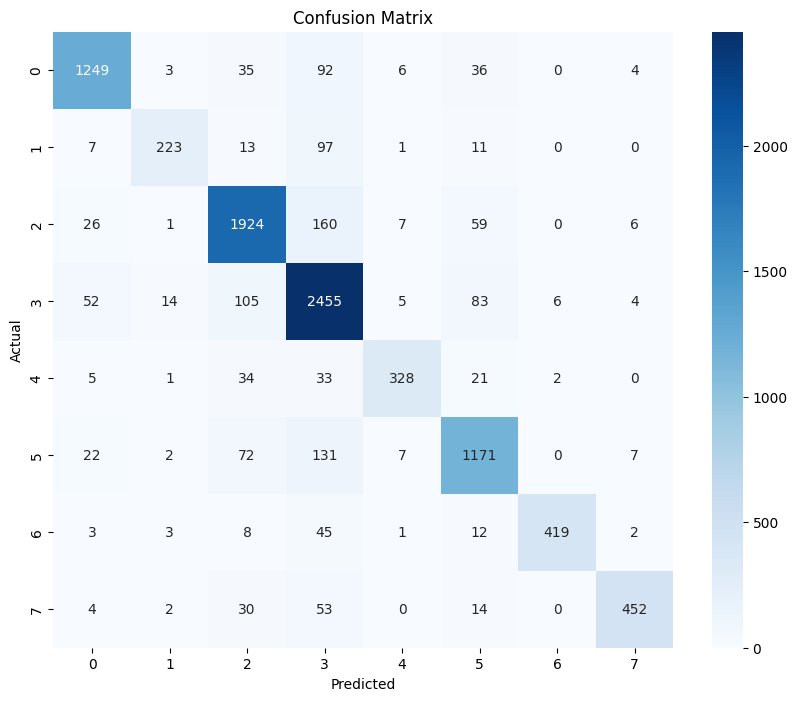

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

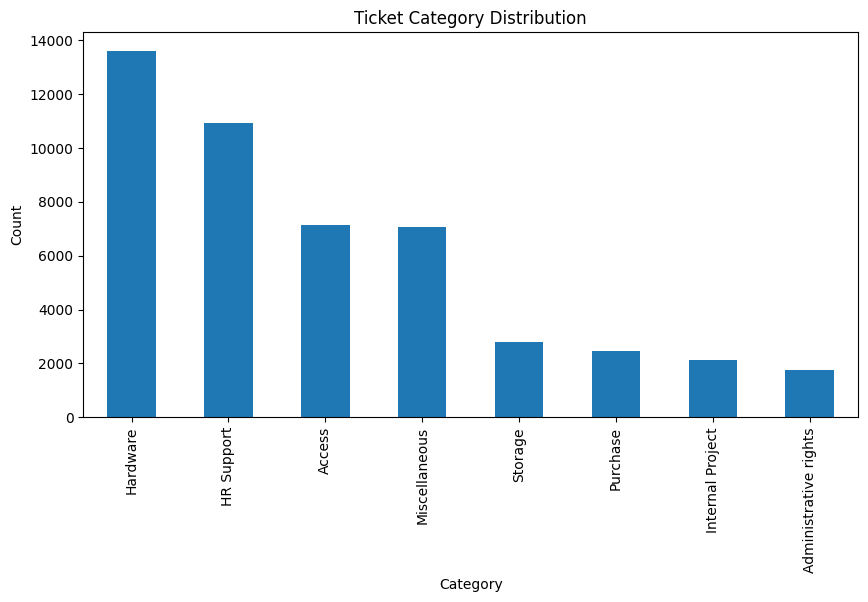

In [17]:
plt.figure(figsize=(10,5))

df['Topic_group'].value_counts().plot(
    kind='bar'
)

plt.title("Ticket Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

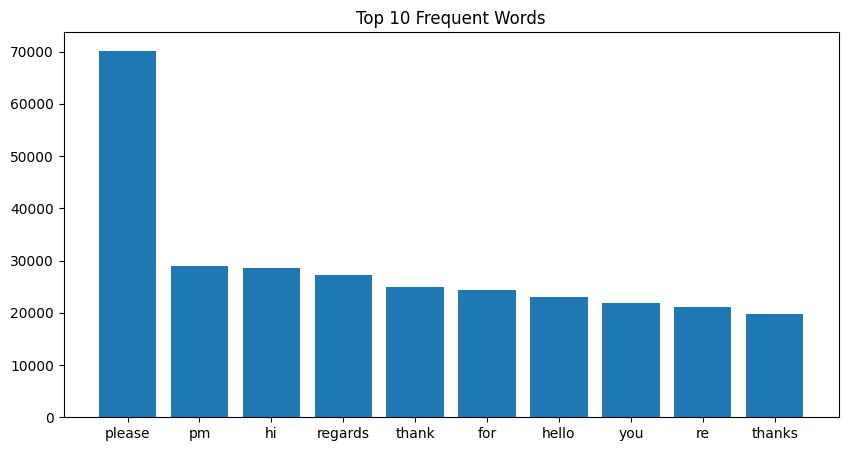

In [18]:
from collections import Counter

all_words = " ".join(df['Document'].astype(str))

words = all_words.split()

word_freq = Counter(words)

top_words = word_freq.most_common(10)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Top 10 Frequent Words")

plt.show()

In [19]:
sample = [
    "Need access to shared drive",
    "Laptop hardware issue",
    "Request for software purchase"
]

sample_tfidf = tfidf.transform(sample)

predictions = model.predict(sample_tfidf)

for text, pred in zip(sample, predictions):
    print(text, "->", pred)

Need access to shared drive -> Storage
Laptop hardware issue -> Hardware
Request for software purchase -> Purchase
